In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"D:\vs_code_ml\knn\Iris.csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


In [5]:
df.shape

(150, 6)

In [6]:
df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

In [7]:
specie=df['Species'].value_counts()
specie

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

<BarContainer object of 3 artists>

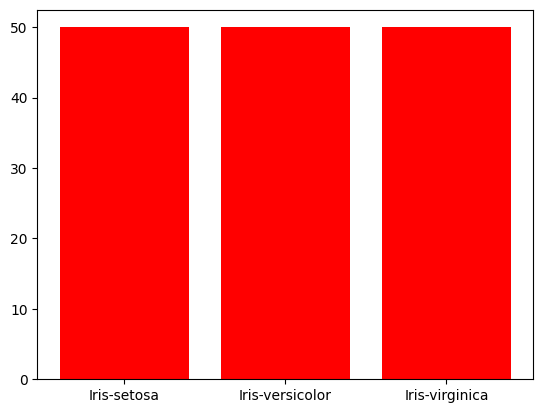

In [8]:
plt.bar(specie.index,specie.values,color='r')

In [9]:
df.isna().sum()


Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [10]:
from sklearn.preprocessing import LabelEncoder
lab=LabelEncoder()
df['Species']=lab.fit_transform(df['Species'])

In [11]:
df=df.drop('Id',axis=1)

In [12]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=1)

In [14]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
scalar.fit(x_train)
x_train=scalar.transform(x_train)
x_test=scalar.transform(x_test)

In [15]:
from keras.models import Sequential
from keras.layers import Dense

In [16]:
ann=Sequential()
#input layer

ann.add(Dense(units=4,activation='relu'))

#hiddenlayer1

ann.add(Dense(units=5,activation='relu'))

#hiddenlayer2
ann.add(Dense(units=4,activation='relu'))

#output layer

ann.add(Dense(units=3,activation='softmax'))

ann.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [17]:
ann.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [18]:
x_train.shape


(105, 4)

In [19]:
ann.fit(x_train,y_train,epochs=100,batch_size=15)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2952 - loss: 1.4588
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2857 - loss: 1.4216 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2476 - loss: 1.3858 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2286 - loss: 1.3549 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1810 - loss: 1.3258 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1524 - loss: 1.2998 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1333 - loss: 1.2764 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1143 - loss: 1.2574 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0952 - loss: 1.2367 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0762 - loss: 1.2205 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0571 - loss: 1.2046 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0381 - loss

In [20]:
ann.evaluate(x_test,y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7111 - loss: 0.4981 


[0.49805882573127747, 0.7111111283302307]

In [21]:
# y_pred=ann.predict()

In [22]:
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (15, 4)                │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (15, 5)                │            25 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (15, 4)                │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (15, 3)                │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 254 (1020.00 B)

 Trainable params: 84 (336.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 170 (684.00 B)

In [23]:
y_new=ann.predict(scalar.transform([[2.3,1,5,3]]))
y_new

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


d:\vs_code_DL\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.7971528 , 0.12122072, 0.08162647]], dtype=float32)

In [24]:
ind=y_new.argmax()
ind

np.int64(0)

In [25]:
pred=lab.inverse_transform([ind])
pred

array(['Iris-setosa'], dtype=object)

In [26]:
y_pred1=ann.predict(x_test)
y_pred2=y_pred1.argmax(axis=1)
y_pred2

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


array([0, 1, 1, 0, 2, 2, 1, 0, 0, 2, 1, 0, 1, 1, 1, 0, 1, 2, 0, 0, 1, 2,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 2, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1])

In [2]:
import tensorflow as tf
import time

print("GPU Available:", tf.config.list_physical_devices("GPU"))

# Simple GPU workload
x = tf.random.normal([10000, 10000])
start = time.time()
y = tf.matmul(x, x)
end = time.time()



GPU Available: []
